In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/comment-category-prediction-challenge/Sample.csv
/kaggle/input/comment-category-prediction-challenge/train.csv
/kaggle/input/comment-category-prediction-challenge/test.csv


In [2]:
import pandas as pd

In [3]:
df_train = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/train.csv")
df_test = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/test.csv")

In [4]:
df_train.head(11)


,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment,label
0,2024-01-18 08:43:57.397508+00:00,73,0,0,0,0,1,0,10,NaN,NaN,NaN,False,She might be a bright spot for a party keou on...,2
1,2024-03-24 21:43:11.490017+00:00,39,0,0,0,6,0,0,4,NaN,NaN,NaN,False,"Under Alaska law, a non-tribal member is not b...",0
2,2024-04-24 20:32:17.014931+00:00,31,0,1,1,0,0,0,10,NaN,NaN,NaN,False,in the future please spare me your strawman dr...,2
3,2023-05-28 22:00:14.214527+00:00,39,0,0,0,5,0,0,10,NaN,NaN,NaN,False,"PS: That should have been ""rot"" instead of ""co...",2
4,2023-09-09 23:12:05.689498+00:00,39,0,0,0,0,0,0,10,NaN,NaN,NaN,False,"Today, the confederate flag...tomorrow, the na...",2
5,2024-04-06 20:10:59.141468+00:00,39,0,0,0,0,0,0,4,NaN,NaN,NaN,False,"Hilarious. Since it wasn't Trump, and that yaw...",0
6,2024-03-04 03:02:55.849172+00:00,72,0,0,0,0,0,0,4,NaN,NaN,NaN,False,Here's an Idea\nState Owned Foreign Companies ...,0
7,2023-10-14 20:57:30.208573+00:00,72,0,0,0,1,1,0,4,NaN,NaN,NaN,False,Victims' participation in the criminla justice...,0
8,2024-02-24 12:13:22.166045+00:00,71,0,0,0,0,0,6,6,none,christian,none,False,I wonder what our ancestors would say when the...,0
9,2023-08-07 20:35:35.968324+00:00,72,1,0,0,6,2,0,4,NaN,NaN,NaN,False,I find it remarkbale that this comment is cons...,0


# MILESTONE-1 CODES

In [5]:
df_train.shape

(198000, 15)

In [6]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102000 entries, 0 to 101999
Data columns (total 14 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   created_date  102000 non-null  object
 1   post_id       102000 non-null  int64 
 2   emoticon_1    102000 non-null  int64 
 3   emoticon_2    102000 non-null  int64 
 4   emoticon_3    102000 non-null  int64 
 5   upvote        102000 non-null  int64 
 6   downvote      102000 non-null  int64 
 7   if_1          102000 non-null  int64 
 8   if_2          102000 non-null  int64 
 9   race          26731 non-null   object
 10  religion      26731 non-null   object
 11  gender        26731 non-null   object
 12  disability    102000 non-null  bool  
 13  comment       102000 non-null  object
dtypes: bool(1), int64(8), object(5)
memory usage: 10.2+ MB


In [7]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198000 entries, 0 to 197999
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   created_date  198000 non-null  object
 1   post_id       198000 non-null  int64 
 2   emoticon_1    198000 non-null  int64 
 3   emoticon_2    198000 non-null  int64 
 4   emoticon_3    198000 non-null  int64 
 5   upvote        198000 non-null  int64 
 6   downvote      198000 non-null  int64 
 7   if_1          198000 non-null  int64 
 8   if_2          198000 non-null  int64 
 9   race          52577 non-null   object
 10  religion      52577 non-null   object
 11  gender        52577 non-null   object
 12  disability    198000 non-null  bool  
 13  comment       197999 non-null  object
 14  label         198000 non-null  int64 
dtypes: bool(1), int64(9), object(5)
memory usage: 21.3+ MB


In [8]:
df_train.isnull().sum()



created_date         0
post_id              0
emoticon_1           0
emoticon_2           0
emoticon_3           0
upvote               0
downvote             0
if_1                 0
if_2                 0
race            145423
religion        145423
gender          145423
disability           0
comment              1
label                0
dtype: int64

In [9]:
df_train['label'].nunique()


4

In [10]:
df_train['label'].value_counts(normalize=True)


label
0    0.576631
2    0.315354
1    0.080394
3    0.027621
Name: proportion, dtype: float64

In [11]:
print(df_train['upvote'].max())
print(df_train['downvote'].max())
print(df_train['if_1'].max())
print(df_train['if_2'].max())
print(df_train['if_2'].min())


201
107
1860
1833
3


In [12]:
df_train['upvote'].median()

1.0

# **MILESTONE-2**

In [13]:
df_temp = df_train.copy()

In [14]:
df_temp['created_date'] = pd.to_datetime(df_temp['created_date'], errors='coerce')

In [15]:
df_temp['month'] = df_temp['created_date'].dt.month_name()

In [16]:
most_common_month = df_temp['month'].value_counts().idxmax().lower()
print(most_common_month)

may


In [17]:
df_temp['total_emoticons'] = (
    df_temp[['emoticon_1', 'emoticon_2', 'emoticon_3']]
        .fillna(0)
        .sum(axis=1)
)
max_total_emoticons = df_temp['total_emoticons'].max()
print(max_total_emoticons)

60


In [18]:
median_length = (
    df_temp[df_temp['label'] == 3]['comment']
        .fillna("")                
        .apply(len)                 
        .median()
)

print(median_length)

128.0


In [19]:
min_upvote = df_temp['upvote'].min()
max_upvote = df_temp['upvote'].max()

print(min_upvote, max_upvote)



0 201


In [20]:
scaled_value = (10 - min_upvote) / (max_upvote - min_upvote)
print(scaled_value)

0.04975124378109453


In [21]:
average_word_count = (
    df_temp[df_temp['label'] == 1]['comment']
        .fillna("")                        
        .apply(lambda x: len(x.split()))    
        .mean()
)

round(average_word_count, 2)

np.float64(57.23)

In [22]:
trump_count = (
    df_temp['comment']
        .fillna("")                                 
        .str.contains("Trump", case=False, na=False)
        .sum()
)

print(trump_count)

24398


In [23]:
import string

# Given stop words
stop_words = ['a', 'an', 'the', 'and', 'or', 'but', 'if', 'because', 'as', 'of', 
              'at', 'by', 'for', 'with', 'about', 'to', 'from', 'up', 'on', 
              'in', 'out', 'over', 'under', 'is', 'are', 'was', 'were', 
              'be', 'been', 'being', 'have', 'has', 'had', 'do', 'does', 
              'did', 'it', 'its', 'they', 'them', 'their', 'she', 'her', 
              'he', 'him', 'his', 'this', 'that', 'which', 'who', 'whom', 
              'i', 'me', 'my', 'we', 'our', 'you', 'your']

# 1️⃣ Extract comment
text = df_temp.loc[0, 'comment']

# Handle missing
if pd.isna(text):
    text = ""

# 2️⃣ Remove punctuation
text = text.translate(str.maketrans('', '', string.punctuation))

# 3️⃣ Convert to lowercase for proper stopword matching
words = text.lower().split()

# 4️⃣ Remove stopwords
filtered_words = [word for word in words if word not in stop_words]

# 5️⃣ Count remaining words
len(filtered_words)

12

In [24]:
# Handle missing values
comments = df_temp['comment'].fillna("")

# Lowercase + tokenize
tokens = comments.str.lower().str.split()

# Flatten list of lists into one list
all_tokens = [token for sublist in tokens for token in sublist]

# Count unique tokens
unique_token_count = len(set(all_tokens))

print(unique_token_count)

425413


In [25]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Handle missing comments
comments = df_temp['comment'].fillna("")

vectorizer = TfidfVectorizer(
    stop_words="english",
    min_df=5,
    ngram_range=(1, 2)
)

X_tfidf = vectorizer.fit_transform(comments)

# Number of features
num_features = len(vectorizer.get_feature_names_out())

print(num_features)

132974


# Milestone-3

# **Milestone-4**

In [26]:
df_train[['race', 'religion', 'gender']].isna().mean()

race        0.73446
religion    0.73446
gender      0.73446
dtype: float64

In [27]:
for col in ['race', 'religion', 'gender']:
    print(f"\n{col.upper()}")
    print(df_train[col].value_counts(dropna=False))
    print("--------***--------")



RACE
race
NaN       145423
none       39682
white       5486
black       3869
other       1654
asian       1263
latino       623
Name: count, dtype: int64
--------***--------

RELIGION
religion
NaN          145423
none          38249
christian      7191
muslim         4930
jewish         1244
other           547
atheist         219
buddhist        100
hindu            97
Name: count, dtype: int64
--------***--------

GENDER
gender
NaN            145423
none            36161
female           8037
male             7549
transgender       622
other             208
Name: count, dtype: int64
--------***--------


In [28]:
empty_or_nan = (
    df_train['comment'].isna() |
    (df_train['comment'].str.strip() == "")
)

empty_or_nan.sum()


np.int64(1)

In [29]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102000 entries, 0 to 101999
Data columns (total 14 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   created_date  102000 non-null  object
 1   post_id       102000 non-null  int64 
 2   emoticon_1    102000 non-null  int64 
 3   emoticon_2    102000 non-null  int64 
 4   emoticon_3    102000 non-null  int64 
 5   upvote        102000 non-null  int64 
 6   downvote      102000 non-null  int64 
 7   if_1          102000 non-null  int64 
 8   if_2          102000 non-null  int64 
 9   race          26731 non-null   object
 10  religion      26731 non-null   object
 11  gender        26731 non-null   object
 12  disability    102000 non-null  bool  
 13  comment       102000 non-null  object
dtypes: bool(1), int64(8), object(5)
memory usage: 10.2+ MB


In [30]:
df_test.isnull().sum()



created_date        0
post_id             0
emoticon_1          0
emoticon_2          0
emoticon_3          0
upvote              0
downvote            0
if_1                0
if_2                0
race            75269
religion        75269
gender          75269
disability          0
comment             0
dtype: int64

In [31]:
df_test[['race', 'religion', 'gender']].isna().mean()


race        0.737931
religion    0.737931
gender      0.737931
dtype: float64

In [32]:
df_train['label'].value_counts()

label
0    114173
2     62440
1     15918
3      5469
Name: count, dtype: int64

**Above we can see that the label distribution is highly biased , so we will do stratified split in later steps.**

In [33]:
df_train['comment_length'] = df_train['comment'].str.len()


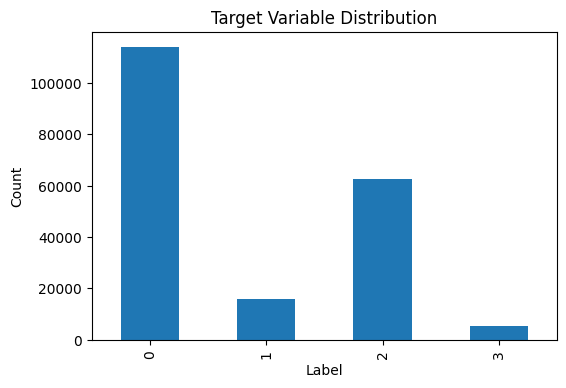

In [34]:
import matplotlib.pyplot as plt

label_counts = df_train['label'].value_counts().sort_index()

plt.figure(figsize=(6,4))
label_counts.plot(kind='bar')
plt.xlabel('Label')
plt.ylabel('Count')
plt.title('Target Variable Distribution')
plt.show()


# **The target variable shows significant class imbalance, with label 0 dominating and label 3 being extremely underrepresented.**

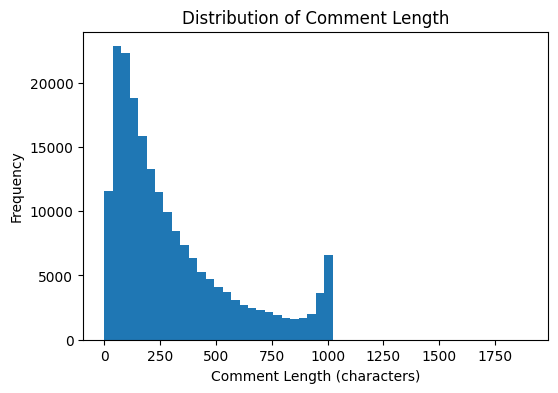

In [35]:
plt.figure(figsize=(6,4))
plt.hist(df_train['comment_length'], bins=50)
plt.xlabel('Comment Length (characters)')
plt.ylabel('Frequency')
plt.title('Distribution of Comment Length')
plt.show()

<Figure size 700x400 with 0 Axes>

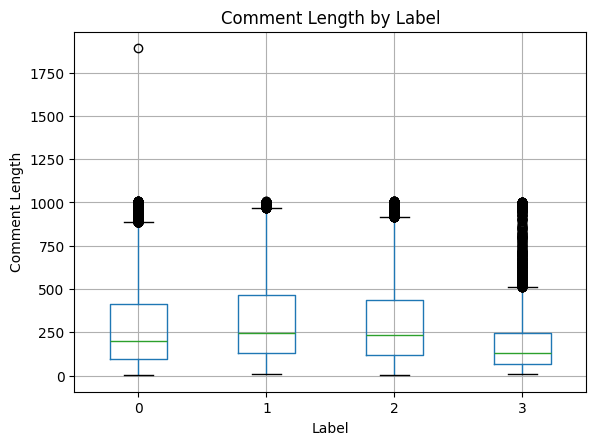

In [36]:
plt.figure(figsize=(7,4))
df_train.boxplot(column='comment_length', by='label')
plt.title('Comment Length by Label')
plt.suptitle('')
plt.xlabel('Label')
plt.ylabel('Comment Length')
plt.show()


# **COMMENT LENGTH PER LABEL** 
**Although comment length differs across labels, there is substantial overlap between classes. Therefore, comment length alone is insufficient for classification and must be combined with content-based textual features.**

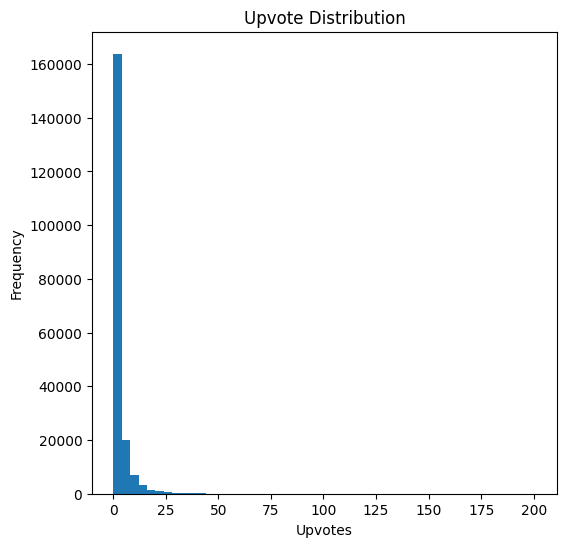

In [37]:
plt.figure(figsize=(6,6))
plt.hist(df_train['upvote'], bins=50)
plt.xlabel('Upvotes')
plt.ylabel('Frequency')
plt.title('Upvote Distribution')
plt.show()


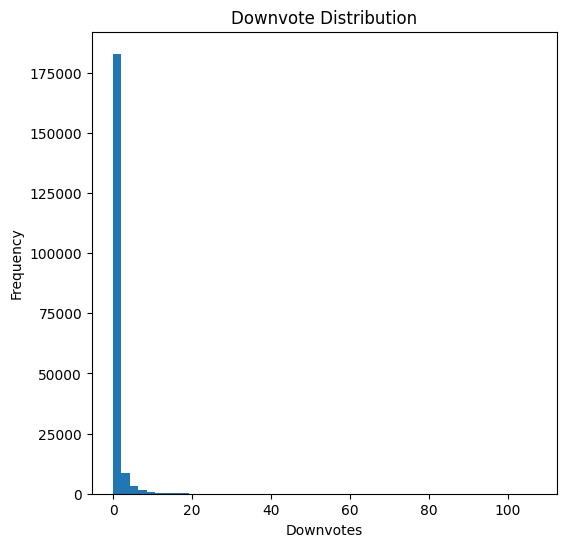

In [38]:
plt.figure(figsize=(6,6))
plt.hist(df_train['downvote'], bins=50)
plt.xlabel('Downvotes')
plt.ylabel('Frequency')
plt.title('Downvote Distribution')
plt.show()


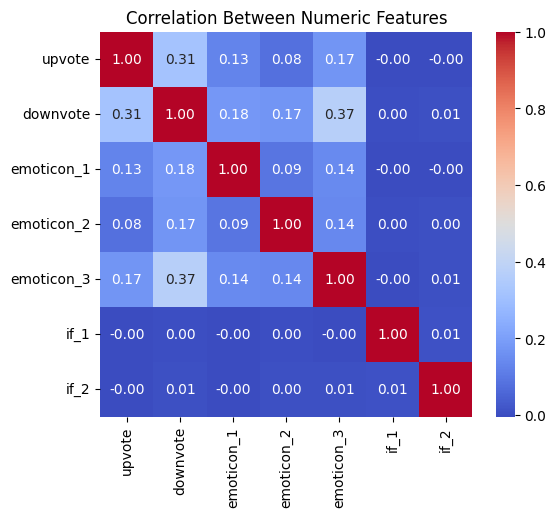

In [39]:
import seaborn as sns


numeric_cols = [
    'upvote', 'downvote',
    'emoticon_1', 'emoticon_2', 'emoticon_3',
    'if_1', 'if_2'
]

corr = df_train[numeric_cols].corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Between Numeric Features')
plt.show()


# **IMPUTATION IN BOTH DATASET****

In [40]:
df_train['comment']=df_train['comment'].fillna("")
df_test['comment']=df_test['comment'].fillna("")

In [41]:
df_train[['race', 'religion', 'gender']]=df_train[['race', 'religion', 'gender']].fillna('none')
df_test[['race', 'religion', 'gender']]=df_test[['race', 'religion', 'gender']].fillna('none')


**VERIFICATON**

In [42]:
df_train[['race', 'religion', 'gender']].isna().sum()
df_test[['race', 'religion', 'gender']].isna().sum()


race        0
religion    0
gender      0
dtype: int64

In [43]:
df_train['comment'].isna().sum()
df_test['comment'].isna().sum()


np.int64(0)

In [44]:
# Comment length features
df_train["char_len"] = df_train["comment"].str.len()
df_train["word_len"] = df_train["comment"].str.split().str.len()

df_test["char_len"] = df_test["comment"].str.len()
df_test["word_len"] = df_test["comment"].str.split().str.len()

In [45]:
df_train["vote_diff"] = df_train["upvote"] - df_train["downvote"]
df_train["vote_sum"] = df_train["upvote"] + df_train["downvote"]
df_train["vote_ratio"] = df_train["upvote"] / (df_train["downvote"] + 1)

df_test["vote_diff"] = df_test["upvote"] - df_test["downvote"]
df_test["vote_sum"] = df_test["upvote"] + df_test["downvote"]
df_test["vote_ratio"] = df_test["upvote"] / (df_test["downvote"] + 1)

In [46]:
df_train["emoticon_total"] = (
    df_train["emoticon_1"] +
    df_train["emoticon_2"] +
    df_train["emoticon_3"]
)

df_test["emoticon_total"] = (
    df_test["emoticon_1"] +
    df_test["emoticon_2"] +
    df_test["emoticon_3"]
)

In [47]:
X = df_train.drop(columns=['label'])
y = df_train['label']

text_col = 'comment'
categorical_cols = ['race', 'religion', 'gender']
numeric_cols = [
'post_id','emoticon_1','emoticon_2','emoticon_3',
'upvote','downvote','if_1','if_2','disability'
]

In [48]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [49]:
print("Train distribution:")
print(y_train.value_counts(normalize=True), "\n")

print("Test (validation) distribution:")
print(y_test.value_counts(normalize=True))


Train distribution:
label
0    0.576629
2    0.315354
1    0.080398
3    0.027620
Name: proportion, dtype: float64 

Test (validation) distribution:
label
0    0.576641
2    0.315354
1    0.080379
3    0.027626
Name: proportion, dtype: float64


**Above we confirmed that the distribution in both y_train and y_test is same.**

In [50]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression


In [51]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            'text',
            TfidfVectorizer(
    ngram_range=(1,3),
    max_features=45000,
    stop_words='english',
    sublinear_tf=True,
    min_df=3
),

            'comment'
        ),
        (
            'cat',
            OneHotEncoder(handle_unknown='ignore'),
            categorical_cols
        ),
        (
            'num',
            'passthrough',
            numeric_cols
        )
    ]
)


In [52]:
baseline_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier',LogisticRegression(
    C=10,
    max_iter=3000,
    class_weight='balanced',
    solver='lbfgs'
)



    )
])


In [53]:
from sklearn.svm import LinearSVC

baseline_model2 = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LinearSVC(
        C=1.5
    ))
])

In [54]:
'''baseline_model.fit(X_train, y_train)'''


'baseline_model.fit(X_train, y_train)'

In [55]:
'''from sklearn.metrics import accuracy_score, f1_score, classification_report

y_pred = baseline_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Macro F1:", f1_score(y_test, y_pred, average='macro'))
print("Weighted F1:", f1_score(y_test, y_pred, average='weighted'))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))'''


'from sklearn.metrics import accuracy_score, f1_score, classification_report\n\ny_pred = baseline_model.predict(X_test)\n\nprint("Accuracy:", accuracy_score(y_test, y_pred))\nprint("Macro F1:", f1_score(y_test, y_pred, average=\'macro\'))\nprint("Weighted F1:", f1_score(y_test, y_pred, average=\'weighted\'))\n\nprint("\nClassification Report:\n")\nprint(classification_report(y_test, y_pred))'

In [56]:
'''baseline_model2.fit(X_train, y_train)
'''

'baseline_model2.fit(X_train, y_train)\n'

In [57]:
'''from sklearn.metrics import accuracy_score, f1_score, classification_report

y_pred = baseline_model2.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Macro F1:", f1_score(y_test, y_pred, average='macro'))
print("Weighted F1:", f1_score(y_test, y_pred, average='weighted'))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))'''


'from sklearn.metrics import accuracy_score, f1_score, classification_report\n\ny_pred = baseline_model2.predict(X_test)\n\nprint("Accuracy:", accuracy_score(y_test, y_pred))\nprint("Macro F1:", f1_score(y_test, y_pred, average=\'macro\'))\nprint("Weighted F1:", f1_score(y_test, y_pred, average=\'weighted\'))\n\nprint("\nClassification Report:\n")\nprint(classification_report(y_test, y_pred))'

In [58]:
'''final_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        C=5,
        max_iter=3000,
        class_weight='balanced',
        solver='lbfgs'
    ))
])

# Train on full training dataset
final_model.fit(X, y)'''


"final_model = Pipeline(steps=[\n    ('preprocessor', preprocessor),\n    ('classifier', LogisticRegression(\n        C=5,\n        max_iter=3000,\n        class_weight='balanced',\n        solver='lbfgs'\n    ))\n])\n\n# Train on full training dataset\nfinal_model.fit(X, y)"

In [59]:
'''baseline_model.fit(X, y)'''

'baseline_model.fit(X, y)'

In [60]:
'''test_preds = baseline_model.predict(df_test)'''


'test_preds = baseline_model.predict(df_test)'

In [61]:
'''sample = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/Sample.csv')

submission = sample.copy()
submission.iloc[:, 1] = test_preds'''

"sample = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/Sample.csv')\n\nsubmission = sample.copy()\nsubmission.iloc[:, 1] = test_preds"

In [62]:
'''submission.to_csv('submission.csv', index=False)

print("Submission file created successfully!")
submission.head()
'''

'submission.to_csv(\'submission.csv\', index=False)\n\nprint("Submission file created successfully!")\nsubmission.head()\n'

In [63]:
"""final_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        max_iter=3000,
        class_weight='balanced'
    ))
])

# Train on FULL data
final_model.fit(X, y)"""

"final_model = Pipeline(steps=[\n    ('preprocessor', preprocessor),\n    ('classifier', LogisticRegression(\n        max_iter=3000,\n        class_weight='balanced'\n    ))\n])\n\n# Train on FULL data\nfinal_model.fit(X, y)"

In [64]:
'''# Generate predictions on Kaggle test set
test_preds = final_model.predict(df_test)   # or svm_model later

# Load sample submission (SOURCE OF TRUTH)
sample = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/Sample.csv')

# Copy structure
submission = sample.copy()

# Replace target column with predictions
submission.iloc[:, 1] = test_preds

# Save file
submission.to_csv('submission.csv', index=False)

print("Submission file created successfully!")
submission.head()'''

'# Generate predictions on Kaggle test set\ntest_preds = final_model.predict(df_test)   # or svm_model later\n\n# Load sample submission (SOURCE OF TRUTH)\nsample = pd.read_csv(\'/kaggle/input/comment-category-prediction-challenge/Sample.csv\')\n\n# Copy structure\nsubmission = sample.copy()\n\n# Replace target column with predictions\nsubmission.iloc[:, 1] = test_preds\n\n# Save file\nsubmission.to_csv(\'submission.csv\', index=False)\n\nprint("Submission file created successfully!")\nsubmission.head()'

MILESTONE_2 COODES

**TUNING USING GRIDSEARCHCV**

In [65]:
'''from sklearn.model_selection import GridSearchCV

param_grid = {
    'classifier__C': [0.1, 1, 5, 10]
}

grid_lr = GridSearchCV(
    baseline_model,
    param_grid,
    scoring='f1_macro',
    cv=3,
    n_jobs=-1
)

grid_lr.fit(X_train, y_train)'''


"from sklearn.model_selection import GridSearchCV\n\nparam_grid = {\n    'classifier__C': [0.1, 1, 5, 10]\n}\n\ngrid_lr = GridSearchCV(\n    baseline_model,\n    param_grid,\n    scoring='f1_macro',\n    cv=3,\n    n_jobs=-1\n)\n\ngrid_lr.fit(X_train, y_train)"

In [66]:
'''grid_lr.best_params_'''


'grid_lr.best_params_'

In [67]:
'''grid_lr.best_score_'''


'grid_lr.best_score_'

Hyperparameter tuning of Logistic Regression using cross-validated macro-F1 did not lead to a significant improvement over the baseline. This suggests that the baseline model was already near-optimal under the chosen feature representation. The tuned model’s cross-validated score closely matches the Kaggle leaderboard score, indicating good generalization.

Leadeerboard score-  0.76262
f2=0.7637

In [68]:
from sklearn.linear_model import SGDClassifier

In [69]:
'''sgd_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', SGDClassifier(
        loss='log_loss',     # logistic regression
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    ))
])'''


"sgd_model = Pipeline(steps=[\n    ('preprocessor', preprocessor),\n    ('classifier', SGDClassifier(\n        loss='log_loss',     # logistic regression\n        class_weight='balanced',\n        max_iter=1000,\n        random_state=42\n    ))\n])"

In [70]:
'''param_grid = {
    'classifier__alpha': [1e-4, 1e-3, 1e-2],
    'classifier__loss': ['log_loss', 'hinge']
}
'''

"param_grid = {\n    'classifier__alpha': [1e-4, 1e-3, 1e-2],\n    'classifier__loss': ['log_loss', 'hinge']\n}\n"

In [71]:
'''grid_sgd = GridSearchCV(
    sgd_model,
    param_grid,
    scoring='f1_macro',
    cv=3,
    n_jobs=-1
)'''

"grid_sgd = GridSearchCV(\n    sgd_model,\n    param_grid,\n    scoring='f1_macro',\n    cv=3,\n    n_jobs=-1\n)"

In [72]:
'''grid_sgd.fit(X_train, y_train)'''


'grid_sgd.fit(X_train, y_train)'

In [73]:
'''best_sgd = grid_sgd.best_estimator_

from sklearn.metrics import accuracy_score, f1_score, classification_report

y_pred = best_sgd.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Macro F1:", f1_score(y_test, y_pred, average='macro'))
print("Weighted F1:", f1_score(y_test, y_pred, average='weighted'))
print(classification_report(y_test, y_pred))'''


'best_sgd = grid_sgd.best_estimator_\n\nfrom sklearn.metrics import accuracy_score, f1_score, classification_report\n\ny_pred = best_sgd.predict(X_test)\n\nprint("Accuracy:", accuracy_score(y_test, y_pred))\nprint("Macro F1:", f1_score(y_test, y_pred, average=\'macro\'))\nprint("Weighted F1:", f1_score(y_test, y_pred, average=\'weighted\'))\nprint(classification_report(y_test, y_pred))'

In [74]:
'''print(grid_sgd.best_estimator_)'''

'print(grid_sgd.best_estimator_)'

**NAIVE BAYES**# 


In [75]:
'''from sklearn.naive_bayes import MultinomialNB

nb_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', MultinomialNB())
])

nb_model.fit(X_train, y_train)'''

"from sklearn.naive_bayes import MultinomialNB\n\nnb_model = Pipeline(steps=[\n    ('preprocessor', preprocessor),\n    ('classifier', MultinomialNB())\n])\n\nnb_model.fit(X_train, y_train)"

In [76]:
'''# Predict on validation set
y_pred_nb = nb_model.predict(X_test)

# Metrics
print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print("Macro F1:", f1_score(y_test, y_pred_nb, average='macro'))
print("Weighted F1:", f1_score(y_test, y_pred_nb, average='weighted'))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_nb))'''

'# Predict on validation set\ny_pred_nb = nb_model.predict(X_test)\n\n# Metrics\nprint("Accuracy:", accuracy_score(y_test, y_pred_nb))\nprint("Macro F1:", f1_score(y_test, y_pred_nb, average=\'macro\'))\nprint("Weighted F1:", f1_score(y_test, y_pred_nb, average=\'weighted\'))\n\nprint("\nClassification Report:\n")\nprint(classification_report(y_test, y_pred_nb))'

In [77]:
'''from sklearn.svm import LinearSVC

svm_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LinearSVC(
        C=1.0,
        class_weight='balanced',
        random_state=42
    ))
])'''

"from sklearn.svm import LinearSVC\n\nsvm_model = Pipeline(steps=[\n    ('preprocessor', preprocessor),\n    ('classifier', LinearSVC(\n        C=1.0,\n        class_weight='balanced',\n        random_state=42\n    ))\n])"

In [78]:
'''svm_model.fit(X_train, y_train)

y_pred = svm_model.predict(X_test)

print("Macro F1:", f1_score(y_test, y_pred, average='macro'))'''

'svm_model.fit(X_train, y_train)\n\ny_pred = svm_model.predict(X_test)\n\nprint("Macro F1:", f1_score(y_test, y_pred, average=\'macro\'))'

In [79]:
'''from lightgbm import LGBMClassifier

lgbm_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LGBMClassifier(
        n_estimators=300,
        learning_rate=0.1,
        max_depth=-1,
        random_state=42
    ))
])'''

"from lightgbm import LGBMClassifier\n\nlgbm_model = Pipeline(steps=[\n    ('preprocessor', preprocessor),\n    ('classifier', LGBMClassifier(\n        n_estimators=300,\n        learning_rate=0.1,\n        max_depth=-1,\n        random_state=42\n    ))\n])"

In [80]:
from lightgbm import LGBMClassifier

lgbm_model2 = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LGBMClassifier(
        n_estimators=800,
        learning_rate=0.05,
        num_leaves=64,
        max_depth=-1,
        min_child_samples=20,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=0.1,
        random_state=42
    ))
])

In [81]:
'''lgbm_model2.fit(X_train, y_train)'''

'lgbm_model2.fit(X_train, y_train)'

In [82]:
'''y_pred = lgbm_model2.predict(X_test)'''

'y_pred = lgbm_model2.predict(X_test)'

In [83]:
lgbm_model2.fit(X, y)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 47.013369 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1119924
[LightGBM] [Info] Number of data points in the train set: 198000, number of used features: 29089
[LightGBM] [Info] Start training from score -0.550552
[LightGBM] [Info] Start training from score -2.520816
[LightGBM] [Info] Start training from score -1.154061
[LightGBM] [Info] Start training from score -3.589171


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('text',
                                                  TfidfVectorizer(max_features=45000,
                                                                  min_df=3,
                                                                  ngram_range=(1,
                                                                               3),
                                                                  stop_words='english',
                                                                  sublinear_tf=True),
                                                  'comment'),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['race', 'religion',
                                                   'gender']),
                                                 ('num', 'passthrough',
                                                  ['post_id', 'emoticon_1',
                                                   'emoticon_2', 'emoticon_3',
                                                   'upvote', 'downvote', 'if_1',
                                                   'if_2', 'disability'])])),
                ('classifier',
                 LGBMClassifier(colsample_bytree=0.8, learning_rate=0.05,
                                n_estimators=800, num_leaves=64,
                                random_state=42, reg_alpha=0.1, reg_lambda=0.1,
                                subsample=0.8))])

In [84]:
'''from sklearn.metrics import accuracy_score, f1_score, classification_report



print("Accuracy:", accuracy_score(y_test, y_pred))
print("Macro F1:", f1_score(y_test, y_pred, average='macro'))
print("Weighted F1:", f1_score(y_test, y_pred, average='weighted'))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))
'''

'from sklearn.metrics import accuracy_score, f1_score, classification_report\n\n\n\nprint("Accuracy:", accuracy_score(y_test, y_pred))\nprint("Macro F1:", f1_score(y_test, y_pred, average=\'macro\'))\nprint("Weighted F1:", f1_score(y_test, y_pred, average=\'weighted\'))\n\nprint("\nClassification Report:\n")\nprint(classification_report(y_test, y_pred))\n'

In [85]:
"""lgbm_model.fit(X, y)"""

'lgbm_model.fit(X, y)'

In [86]:
test_preds = lgbm_model2.predict(df_test)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [87]:
sample = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/Sample.csv')

submission = sample.copy()
submission.iloc[:,1] = test_preds

submission.to_csv('/kaggle/working/submission.csv', index=False)